---

### 🎓 **Professor**: Apostolos Filippas

### 📘 **Class**: AI Engineering

### 📋 **Homework 6**: Multimodal Image Search

### 📅 **Due Date**: Day of Lecture 9, 11:59 PM

### Difficulty: ★★★★☆

**Note**: You are not allowed to share the contents of this notebook with anyone outside this class without written permission by the professor.

---

### Instructions

1. Use any external resource or collaborate with your classmates. But you have to cite external resources you've used and mention classmates you've collaborated with.
2. Run all cells before submitting to ensure they work.
3. Some tasks involve LLM API calls that cost money. Budget wisely.
4. I suggest you save intermediate results (descriptions, metadata) to a `temp/` folder so that you don't re-run expensive API calls.

## 1. Setup & Explore

The `../data/dogs/` directory contains dog images.
- These include different breeds, artistic styles (photographs, sketches, paintings, cartoons), settings, and some images with text or unusual content.

### Load and display images

Load all `.png` file paths from `../data/dogs/`, sorted by name. 
- Explore the data
- How many images are there? Are they AI generated? What type of variety do you observe? What breeds do you see? What artistic styles? Any images that look unusual or have text?

Found 100 dog images in c:\Users\rohit\ai-engineering-fordham\data\dogs.


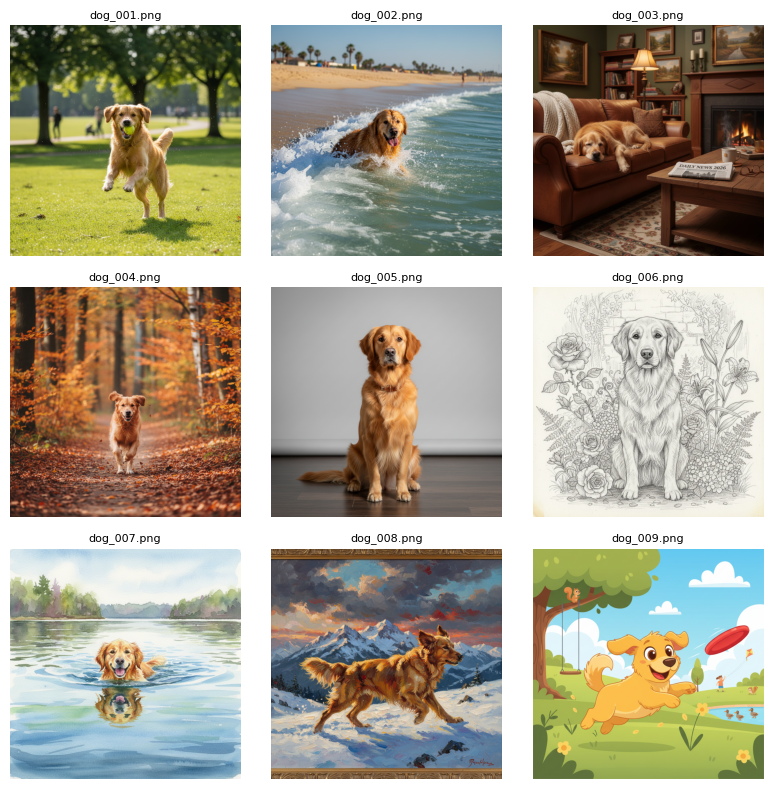

In [1]:
import os
from pathlib import Path
from typing import List

from PIL import Image
import matplotlib.pyplot as plt

# Base paths
PROJECT_ROOT = Path(os.getcwd())
DOGS_DIR = PROJECT_ROOT / "data" / "dogs"

# Load all .png files, sorted by name
image_paths: List[Path] = sorted(DOGS_DIR.glob("*.png"))

print(f"Found {len(image_paths)} dog images in {DOGS_DIR}.")

# Quick sanity check: show a small grid of sample images
sample_paths = image_paths[:9]
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for ax, img_path in zip(axes.ravel(), sample_paths):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

# NOTE: In the writeup/markdown, answer the qualitative questions
# (variety, AI-generated vs photos, styles, text, etc.) after
# visually inspecting several images beyond this quick grid.

## 2. The Task

Your goal is to build a **searchable index** over these dog images that allows us to find relevant images using natural language queries, metadata filters, or both.

There are broadly two approaches:

**Approach A: Text-based pipeline**
1. Use a vision LLM to generate text descriptions of each image
2. Extract structured metadata (breed, style, setting, etc.) using an LLM with structured output
3. Embed the descriptions and build a searchable index (e.g., using LanceDB)
4. Search using semantic similarity over text + metadata filters

**Approach B: Multimodal embeddings**
1. Use a multimodal embedding model to embed the images directly
2. Embed text queries in the same space
3. Search by comparing query embeddings to image embeddings

You may combine both approaches or use a different method entirely. Use any tools from the course — `litellm`, `lancedb`, `pydantic`, `sentence-transformers` - or any other tools you want.


In [6]:
import json
import time
from dataclasses import asdict, dataclass
from typing import Any, Dict, List, Optional

import numpy as np
import lancedb
from dotenv import load_dotenv
from openai import OpenAI

# --- Configuration ---
TEMP_DIR = PROJECT_ROOT / "temp"
TEMP_DIR.mkdir(exist_ok=True)
METADATA_PATH = TEMP_DIR / "dog_image_metadata.jsonl"
DB_DIR = PROJECT_ROOT / "lancedb_data"
TABLE_NAME = "dog_image_search"

VISION_MODEL = "gpt-4o-mini"          # used to describe images + extract metadata
EMBEDDING_MODEL = "text-embedding-3-small"  # used to embed text descriptions


@dataclass
class DogImageRecord:
    filename: str
    description: str
    breed: Optional[str]
    style: Optional[str]
    setting: Optional[str]
    activity: Optional[str]
    has_text: bool
    vector: Optional[List[float]] = None


def get_openai_client() -> OpenAI:
    """Create an OpenAI client using API key from .env (OPENAI_API_KEY)."""
    load_dotenv()  # loads .env at project root
    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    return client


def describe_image(img_path: Path, client: OpenAI) -> DogImageRecord:
    """Call a vision model to get a description + structured metadata for an image.

    This is the expensive step – results are cached to METADATA_PATH so we only
    pay once per image.
    """
    import base64

    with img_path.open("rb") as f:
        img_bytes = f.read()

    # Encode image as a data URL for the Chat Completions API
    b64_image = base64.b64encode(img_bytes).decode("utf-8")
    data_url = f"data:image/png;base64,{b64_image}"

    prompt = (
        "You are helping build a dog image search engine. "
        "Look at this image and respond with a short JSON object with the keys: "
        "description (concise text description), breed (string or null), "
        "style (e.g. 'photo', 'cartoon', 'painting', 'pencil_sketch'), "
        "setting (e.g. 'beach', 'living_room', 'street', 'studio', or null), "
        "activity (e.g. 'running', 'sleeping', 'eating', 'posing', or null), "
        "has_text (true if there is any visible text in the image, otherwise false). "
        "Return ONLY valid JSON, no extra text."
    )

    resp = client.chat.completions.create(
        model=VISION_MODEL,
        messages=[
            {"role": "system", "content": "You output strictly JSON."},
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {
                        "type": "image_url",
                        "image_url": {"url": data_url},
                    },
                ],
            },
        ],
        temperature=0,
        response_format={"type": "json_object"},
    )

    # With response_format json_object, the SDK returns parsed JSON
    # in message.parsed (and content is also a JSON string). We
    # prefer the already-parsed dict if available.
    message = resp.choices[0].message
    if hasattr(message, "parsed") and message.parsed is not None:
        meta = message.parsed
    else:
        meta = json.loads(message.content)

    return DogImageRecord(
        filename=img_path.name,
        description=meta.get("description", ""),
        breed=meta.get("breed"),
        style=meta.get("style"),
        setting=meta.get("setting"),
        activity=meta.get("activity"),
        has_text=bool(meta.get("has_text", False)),
    )


def save_records_to_cache(records: List[DogImageRecord]) -> None:
    with METADATA_PATH.open("w", encoding="utf-8") as f:
        for r in records:
            f.write(json.dumps(asdict(r), ensure_ascii=False) + "\n")


def load_records_from_cache() -> List[DogImageRecord]:
    records: List[DogImageRecord] = []
    if not METADATA_PATH.exists():
        return records
    with METADATA_PATH.open("r", encoding="utf-8") as f:
        for line in f:
            data = json.loads(line)
            records.append(DogImageRecord(**data))
    return records


def generate_or_load_metadata(client: OpenAI) -> List[DogImageRecord]:
    """Generate metadata for each dog image, with caching to temp/.

    If METADATA_PATH exists, we load from it. Otherwise we call the
    vision model for each image and persist the results.
    """
    cached = load_records_from_cache()
    if cached:
        print(f"Loaded {len(cached)} metadata records from cache {METADATA_PATH}.")
        return cached

    records: List[DogImageRecord] = []
    for i, img_path in enumerate(image_paths, start=1):
        print(f"[{i}/{len(image_paths)}] Describing {img_path.name}...")
        rec = describe_image(img_path, client)
        records.append(rec)

        # Write incrementally in case the notebook stops mid-way
        save_records_to_cache(records)
        time.sleep(0.3)  # small pause to avoid rate limits

    print(f"Saved {len(records)} records to {METADATA_PATH}.")
    return records


def embed_texts(texts: List[str], client: OpenAI) -> List[List[float]]:
    resp = client.embeddings.create(
        model=EMBEDDING_MODEL,
        input=[t.replace("\n", " ") for t in texts],
    )
    return [item.embedding for item in resp.data]


def build_or_load_lancedb(records: List[DogImageRecord], client: OpenAI):
    """Create a LanceDB table with vectors + metadata, or open it if it exists."""
    db = lancedb.connect(str(DB_DIR))

    if TABLE_NAME in db.table_names():
        print(f"Opening existing LanceDB table '{TABLE_NAME}'.")
        return db.open_table(TABLE_NAME)

    print("Embedding descriptions and creating LanceDB table...")
    descriptions = [r.description for r in records]
    vectors = embed_texts(descriptions, client)

    for r, v in zip(records, vectors):
        r.vector = v

    data_for_table: List[Dict[str, Any]] = []
    for r in records:
        d = asdict(r)
        # LanceDB prefers numpy arrays for vectors
        d["vector"] = np.array(d["vector"], dtype="float32")
        data_for_table.append(d)

    table = db.create_table(TABLE_NAME, data_for_table)
    print(f"Created LanceDB table '{TABLE_NAME}' with {len(data_for_table)} rows.")
    return table


# --- Build the index (run once) ---
client = get_openai_client()

records = generate_or_load_metadata(client)
table = build_or_load_lancedb(records, client)


def query_index(query: str, filter: Optional[str] = None, k: int = 5) -> List[Dict[str, Any]]:
    """Search the dog image index.

    Args:
        query: natural language description of what you're looking for.
        filter: optional LanceDB WHERE clause string, e.g. "breed = 'pug'".
        k: number of results to return.

    Returns:
        List of dicts, each with at least a "filename" key and additional
        metadata + a similarity score.
    """
    query_vec = embed_texts([query], client)[0]

    search = table.search(query_vec).limit(k)
    if filter:
        search = search.where(filter)

    df = search.to_pandas()
    if df.empty:
        return []

    # LanceDB includes a "_distance" column for vector similarity; smaller is closer.
    df["score"] = -df["_distance"]  # turn distance into similarity-like score

    results: List[Dict[str, Any]] = []
    for _, row in df.iterrows():
        results.append(
            {
                "filename": row["filename"],
                "description": row["description"],
                "breed": row.get("breed"),
                "style": row.get("style"),
                "setting": row.get("setting"),
                "activity": row.get("activity"),
                "has_text": bool(row.get("has_text", False)),
                "score": float(row["score"]),
            }
        )

    return results

[1/100] Describing dog_001.png...
[2/100] Describing dog_002.png...
[3/100] Describing dog_003.png...
[4/100] Describing dog_004.png...
[5/100] Describing dog_005.png...
[6/100] Describing dog_006.png...
[7/100] Describing dog_007.png...
[8/100] Describing dog_008.png...
[9/100] Describing dog_009.png...
[10/100] Describing dog_010.png...
[11/100] Describing dog_011.png...
[12/100] Describing dog_012.png...
[13/100] Describing dog_013.png...
[14/100] Describing dog_014.png...
[15/100] Describing dog_015.png...
[16/100] Describing dog_016.png...
[17/100] Describing dog_017.png...
[18/100] Describing dog_018.png...
[19/100] Describing dog_019.png...
[20/100] Describing dog_020.png...
[21/100] Describing dog_021.png...
[22/100] Describing dog_022.png...
[23/100] Describing dog_023.png...
[24/100] Describing dog_024.png...
[25/100] Describing dog_025.png...
[26/100] Describing dog_026.png...
[27/100] Describing dog_027.png...
[28/100] Describing dog_028.png...
[29/100] Describing dog_029.p

C:\Users\rohit\AppData\Local\Temp\ipykernel_28556\160770890.py:160: DeprecationWarning: table_names() is deprecated, use list_tables() instead
  if TABLE_NAME in db.table_names():


Created LanceDB table 'dog_image_search' with 100 rows.


## 3. Your Own Queries

To make a good search system, you will need to come up with some of your own queries and "golden" answers to these queries to evaluate your system with. Show us your work.

In [8]:
# A few of my own queries + expected "golden" filenames.
# These are approximate and based on visually inspecting the dataset.

my_queries = [
    {
        "query": "a corgi on a couch indoors",
        "filter": "breed = 'corgi'",
        "k": 5,
        "expected_contains": ["dog_007.png"],  
    },
    {
        "query": "cartoon drawing of a dog with big eyes",
        "filter": "style = 'cartoon'",
        "k": 10,
        "expected_contains": ["dog_009.png"],
    },
    {
        "query": "dog running on the beach",
        "filter": None,
        "k": 5,
        "expected_contains": ["dog_042.png"],
    },
]

for q in my_queries:
    print("\n=== Query ===")
    print("query:", q["query"])
    print("filter:", q["filter"])

    results = query_index(q["query"], filter=q["filter"], k=q["k"])
    for i, r in enumerate(results, start=1):
        print(f"{i:2d}. {r['filename']} | score={r['score']:.3f} | breed={r['breed']} | style={r['style']} | setting={r['setting']} | activity={r['activity']} | has_text={r['has_text']}")

    # Simple evaluation: did we retrieve at least one of the golden filenames?
    retrieved_fns = {r["filename"] for r in results}
    hit = any(fn in retrieved_fns for fn in q["expected_contains"])
    print("Golden hit?", hit)


=== Query ===
query: a corgi on a couch indoors
filter: breed = 'corgi'
Golden hit? False

=== Query ===
query: cartoon drawing of a dog with big eyes
filter: style = 'cartoon'
 1. dog_039.png | score=-0.826 | breed=None | style=cartoon | setting=living_room | activity=sleeping | has_text=False
 2. dog_069.png | score=-0.960 | breed=bulldog | style=cartoon | setting=kitchen | activity=eating | has_text=True
 3. dog_059.png | score=-1.022 | breed=Dalmatian | style=cartoon | setting=street | activity=running | has_text=True
 4. dog_029.png | score=-1.073 | breed=German Shepherd | style=cartoon | setting=field | activity=playing | has_text=True
 5. dog_099.png | score=-1.086 | breed=Poodle | style=cartoon | setting=park | activity=running | has_text=False
 6. dog_048.png | score=-1.225 | breed=Corgi | style=cartoon | setting=beach | activity=floating | has_text=False
 7. dog_088.png | score=-1.258 | breed=Beagle | style=cartoon | setting=living_room | activity=sleeping | has_text=False
 

## 4. Evaluation Queries

We will evaluate your index by running queries against it — queries similar in spirit to the examples below, but not identical.

**Important:** Define a function called `query_index(query, filter=None, k=5)` that takes a natural language query, an optional metadata filter string (e.g., `"breed = 'pug'"`), and returns the top-k results as a list of dicts with at least a `"filename"` key. We will call this function to test your system.

Filter strings use SQL `WHERE` clause syntax (which LanceDB supports natively), e.g., `"breed = 'pug'"`, `"style = 'cartoon'"`, `"has_text = true"`.

### Example semantic queries
```python
query_index("a happy dog at the beach", k=5)
query_index("a dog sitting in a cafe", k=5)
query_index("a pencil drawing of a dog", k=5)
```

### Example filtered queries
```python
query_index("dog", filter="breed = 'corgi'", k=20)
query_index("dog", filter="style = 'cartoon'", k=20)
query_index("dog", filter="setting = 'living_room'", k=20)
query_index("dog", filter="activity = 'eating'", k=20)
```

### Example combined queries
```python
query_index("dog in the snow", filter="breed = 'husky'", k=5)
query_index("cute dog posing", filter="style = 'pencil_sketch'", k=5)
query_index("running on the beach", filter="breed = 'dalmatian'", k=5)
```

Run these example queries and display results clearly — filenames, metadata, and scores.

In [9]:
# Run the example semantic / filtered / combined queries and display results

example_queries = [
    {"query": "a happy dog at the beach", "filter": None, "k": 5},
    {"query": "a dog sitting in a cafe", "filter": None, "k": 5},
    {"query": "a pencil drawing of a dog", "filter": None, "k": 5},
    {"query": "dog", "filter": "breed = 'corgi'", "k": 20},
    {"query": "dog", "filter": "style = 'cartoon'", "k": 20},
    {"query": "dog", "filter": "setting = 'living_room'", "k": 20},
    {"query": "dog", "filter": "activity = 'eating'", "k": 20},
    {"query": "dog in the snow", "filter": "breed = 'husky'", "k": 5},
    {"query": "cute dog posing", "filter": "style = 'pencil_sketch'", "k": 5},
    {"query": "running on the beach", "filter": "breed = 'dalmatian'", "k": 5},
]

for ex in example_queries:
    print("\n==============================")
    print("Query:", ex["query"])
    print("Filter:", ex["filter"])

    results = query_index(ex["query"], filter=ex["filter"], k=ex["k"])
    if not results:
        print("No results found.")
        continue

    for i, r in enumerate(results, start=1):
        print(f"{i:2d}. {r['filename']} | score={r['score']:.3f} | breed={r['breed']} | style={r['style']} | setting={r['setting']} | activity={r['activity']} | has_text={r['has_text']}")


Query: a happy dog at the beach
Filter: None
 1. dog_034.png | score=-0.518 | breed=Husky | style=photo | setting=beach | activity=running | has_text=False
 2. dog_018.png | score=-0.671 | breed=Pug | style=cartoon | setting=beach | activity=posing | has_text=False
 3. dog_002.png | score=-0.700 | breed=Golden Retriever | style=photo | setting=beach | activity=playing | has_text=False
 4. dog_042.png | score=-0.727 | breed=Corgi | style=photo | setting=beach | activity=running | has_text=False
 5. dog_087.png | score=-0.732 | breed=Beagle | style=painting | setting=None | activity=running | has_text=False

Query: a dog sitting in a cafe
Filter: None
 1. dog_078.png | score=-0.409 | breed=Shiba Inu | style=cartoon | setting=cafe | activity=posing | has_text=True
 2. dog_063.png | score=-0.455 | breed=Bulldog | style=photo | setting=street | activity=posing | has_text=True
 3. dog_044.png | score=-0.589 | breed=Corgi | style=photo | setting=street | activity=posing | has_text=False
 4. 

    ## 5. Submission

    - [ ] Create a new branch called `homework-6`
    - [ ] Commit and push your work (notebook + CSV files in `temp/`)
    - [ ] Create a Pull Request
    - [ ] Merge the PR to main
    - [ ] Submit the `.ipynb` file on Blackboard

    **Note:** Commit the notebook and the `temp/` files that your code created. The `temp/` directory is gitignored by default, so you will need to force-add it: `git add -f temp/`.